In [16]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("harrisonlou/imu-glove", output_dir="./imu_data")

print("Path to dataset files:", path)

Path to dataset files: ./imu_data


In [17]:
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

## Stationary

### Load Data

In [18]:
stationary_df = pl.read_csv("./imu_data/rosbag/data/data/rosbag2_2023_02_10-06_45_38_data.csv")

stationary_df

timestamp,Imu0_linear_accleration_x,Imu0_linear_accleration_y,Imu0_linear_accleration_z,Imu0_angular_velocity_x,Imu0_angular_velocity_y,Imu0_angular_velocity_z,Imu0_orientation_x,Imu0_orientation_y,Imu0_orientation_z,Imu0_orientation_w,Imu1_linear_accleration_x,Imu1_linear_accleration_y,Imu1_linear_accleration_z,Imu1_angular_velocity_x,Imu1_angular_velocity_y,Imu1_angular_velocity_z,Imu1_orientation_x,Imu1_orientation_y,Imu1_orientation_z,Imu1_orientation_w,Imu2_linear_accleration_x,Imu2_linear_accleration_y,Imu2_linear_accleration_z,Imu2_angular_velocity_x,Imu2_angular_velocity_y,Imu2_angular_velocity_z,Imu2_orientation_x,Imu2_orientation_y,Imu2_orientation_z,Imu2_orientation_w,imu0_to_imu1_translation_x,imu0_to_imu1_translation_y,imu0_to_imu1_translation_z,imu0_to_imu1_rotation_x,imu0_to_imu1_rotation_y,imu0_to_imu1_rotation_z,imu0_to_imu1_rotation_w,imu0_to_imu2_translation_x,imu0_to_imu2_translation_y,imu0_to_imu2_translation_z,imu0_to_imu2_rotation_x,imu0_to_imu2_rotation_y,imu0_to_imu2_rotation_z,imu0_to_imu2_rotation_w
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1.6760e9,2.54,1.58,9.23,0.08,0.03,0.0,-0.112775,0.106106,-0.246343,-0.956733,-9.09,3.46,1.69,0.07,-0.14,-0.01,0.63577,0.087269,-0.672306,0.369032,-8.48,4.29,0.24,0.14,0.1,-0.01,0.175781,-0.870102,0.057416,-0.456867,1.185552,1.720877,-0.505518,0.0,0.0,0.0,1.0,-1.082675,-0.475089,1.795719,0.0,0.0,0.0,1.0
1.6760e9,2.52,1.58,9.11,0.09,0.02,0.01,-0.115793,0.107951,-0.246661,-0.956084,-8.97,3.51,1.62,0.07,-0.13,-0.02,0.636442,0.085338,-0.672339,0.368264,-8.4,4.33,0.21,0.15,0.1,-0.01,0.173852,-0.870369,0.058446,-0.456965,1.176419,1.72904,-0.498959,0.0,0.0,0.0,1.0,-1.086171,-0.478506,1.792698,0.0,0.0,0.0,1.0
1.6760e9,2.52,1.66,9.18,0.1,0.03,0.01,-0.123049,0.102659,-0.246421,-0.955823,-8.98,3.51,1.75,0.07,-0.14,0.04,0.635022,0.077143,-0.672948,0.371398,-8.42,4.34,0.27,0.15,0.11,0.04,0.168887,-0.871253,0.059768,-0.456972,1.167818,1.736227,-0.494184,0.0,0.0,0.0,1.0,-1.079624,-0.476662,1.797138,0.0,0.0,0.0,1.0
1.6760e9,2.6,1.56,9.16,0.09,0.06,0.01,-0.122018,0.103595,-0.24729,-0.955629,-9.03,3.44,1.65,0.06,-0.14,0.04,0.635061,0.076948,-0.673791,0.36984,-8.5,4.25,0.3,0.15,0.11,0.04,0.166413,-0.871674,0.060443,-0.456988,1.167899,1.736753,-0.49214,0.0,0.0,0.0,1.0,-1.078366,-0.487838,1.794893,0.0,0.0,0.0,1.0
1.6760e9,2.56,1.61,9.19,0.1,0.02,0.01,-0.120954,0.104999,-0.24821,-0.955373,-9.03,3.41,1.67,0.07,-0.14,0.02,0.635005,0.076999,-0.675028,0.367665,-8.5,4.25,0.26,0.15,0.09,-0.0,0.164237,-0.871875,0.061447,-0.457257,1.167628,1.737456,-0.4903,0.0,0.0,0.0,1.0,-1.077803,-0.500051,1.791868,0.0,0.0,0.0,1.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
1.6760e9,2.33,1.78,9.16,0.11,0.05,0.03,-0.138204,0.070368,-0.404208,-0.901423,-8.93,3.66,2.02,0.04,-0.12,0.03,0.56595,-0.274185,-0.776725,-0.034957,-8.35,4.47,0.37,0.13,0.08,0.03,-0.494019,-0.734218,0.297381,-0.358376,0.393072,2.111223,0.103589,0.0,0.0,0.0,1.0,0.018131,-2.087109,0.515894,0.0,0.0,0.0,1.0
1.6760e9,2.28,1.8,9.15,0.12,0.01,0.02,-0.137227,0.07044,-0.404891,-0.901261,-8.93,3.59,1.9,0.05,-0.14,0.01,0.566016,-0.273986,-0.776669,-0.036637,-8.4,4.4,0.35,0.13,0.08,0.02,-0.495223,-0.733286,0.297786,-0.358286,0.391015,2.111572,0.104269,0.0,0.0,0.0,1.0,0.019863,-2.088876,0.50863,0.0,0.0,0.0,1.0
1.6760e9,2.31,1.8,9.22,0.1,0.01,-0.0,-0.136255,0.07212,-0.405614,-0.90095,-9.0,3.59,1.89,0.09,-0.11,-0.03,0.566736,-0.273986,-0.775981,-0.039953,-8.42,4.36,0.25,0.16,0.1,-0.03,-0.496699,-0.732277,0.298955,-0.357332,0.38103,2.113187,0.108421,0.0,0.0,0.0,1.0,0.020505,-2.090363,0.502455,0.0,0.0,0.0,1.0


In [19]:
def get_column_combos(imus, dims, readings):
    columns = [f"Imu{im}_{read}_{dim}" for im in imus for read in readings for dim in dims]
    return columns

imus = [0, 1]
dims = ["x", "y", "z"]
readings = ["linear_accleration", "angular_velocity"]

stationary_df = stationary_df.select(
    ["timestamp"] + get_column_combos(imus, dims, readings)
).with_columns(
    pl.from_epoch("timestamp", time_unit="s")
)

stationary_df.head()

timestamp,Imu0_linear_accleration_x,Imu0_linear_accleration_y,Imu0_linear_accleration_z,Imu0_angular_velocity_x,Imu0_angular_velocity_y,Imu0_angular_velocity_z,Imu1_linear_accleration_x,Imu1_linear_accleration_y,Imu1_linear_accleration_z,Imu1_angular_velocity_x,Imu1_angular_velocity_y,Imu1_angular_velocity_z
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2023-02-10 06:45:38.817525,2.54,1.58,9.23,0.08,0.03,0.0,-9.09,3.46,1.69,0.07,-0.14,-0.01
2023-02-10 06:45:38.849536,2.52,1.58,9.11,0.09,0.02,0.01,-8.97,3.51,1.62,0.07,-0.13,-0.02
2023-02-10 06:45:38.909733,2.52,1.66,9.18,0.1,0.03,0.01,-8.98,3.51,1.75,0.07,-0.14,0.04
2023-02-10 06:45:38.939856,2.6,1.56,9.16,0.09,0.06,0.01,-9.03,3.44,1.65,0.06,-0.14,0.04
2023-02-10 06:45:38.973747,2.56,1.61,9.19,0.1,0.02,0.01,-9.03,3.41,1.67,0.07,-0.14,0.02


### Visual

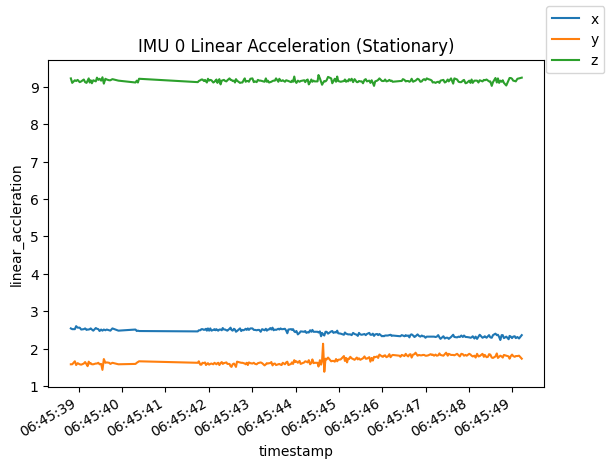

In [20]:
def plot_readings(df, imu: str, title: str, reading: str, dims: list[str] = ["x", "y", "z"]):
    fig, ax = plt.subplots()

    for dim in dims:
        ax.plot(
            df["timestamp"],
            df[f"{imu}_{reading}_{dim}"],
            label=dim
        )

    ax.set_title(title) # 'IMU 0 Linear Acceleration (Stationary)'
    ax.set_xlabel('timestamp')
    ax.set_ylabel(reading)
    ax.xaxis.set_major_locator(mdates.SecondLocator(interval=1))
    fig.autofmt_xdate()
    fig.legend()

    plt.show()

plot_readings(
    stationary_df,
    "Imu0",
    "IMU 0 Linear Acceleration (Stationary)",
    "linear_accleration"
)

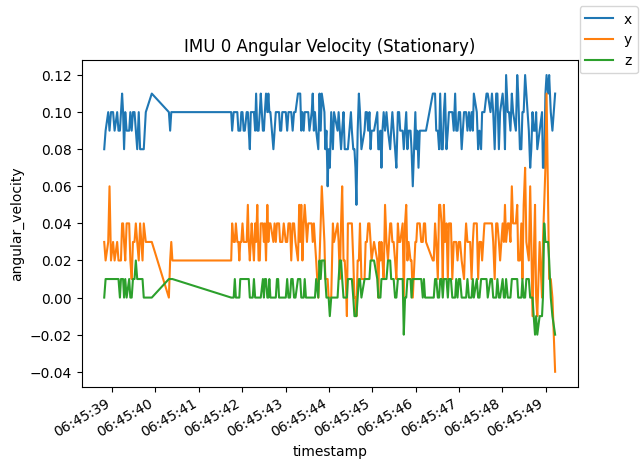

In [21]:
plot_readings(
    stationary_df,
    "Imu0",
    "IMU 0 Angular Velocity (Stationary)",
    "angular_velocity"
)

## Slide Up

### Load Data

In [22]:
slide_up_df = pl.read_csv("./imu_data/rosbag/data/data/rosbag2_2023_02_10-07_52_42_data.csv").select(
    ["timestamp"] + get_column_combos(imus, dims, readings)
).with_columns(
    pl.from_epoch("timestamp", time_unit="s")
)

slide_up_df

timestamp,Imu0_linear_accleration_x,Imu0_linear_accleration_y,Imu0_linear_accleration_z,Imu0_angular_velocity_x,Imu0_angular_velocity_y,Imu0_angular_velocity_z,Imu1_linear_accleration_x,Imu1_linear_accleration_y,Imu1_linear_accleration_z,Imu1_angular_velocity_x,Imu1_angular_velocity_y,Imu1_angular_velocity_z
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2023-02-10 07:52:45.791739,0.57,1.04,9.44,0.24,-0.09,0.02,-9.0,1.82,2.91,0.08,-0.16,0.02
2023-02-10 07:52:45.816029,0.71,1.18,9.44,0.02,0.13,-0.01,-9.14,1.92,3.08,0.08,-0.12,-0.0
2023-02-10 07:52:45.849457,0.78,1.24,9.54,0.07,0.03,0.0,-9.35,2.02,3.1,0.06,-0.15,0.0
2023-02-10 07:52:45.877149,0.73,1.17,9.57,0.16,-0.03,0.02,-9.15,1.97,3.11,0.06,-0.17,0.03
2023-02-10 07:52:45.946374,0.57,1.03,9.35,0.14,-0.02,0.02,-8.93,1.87,3.0,0.05,-0.13,-0.0
…,…,…,…,…,…,…,…,…,…,…,…,…
2023-02-10 07:52:50.210274,-8.63,1.17,3.78,0.12,0.06,0.0,-5.99,1.73,-7.47,0.08,-0.15,0.05
2023-02-10 07:52:50.241047,-8.66,1.25,3.85,0.11,-0.02,0.03,-5.28,1.7,-7.45,0.03,-0.18,0.04
2023-02-10 07:52:50.273250,-8.71,1.11,3.72,0.11,0.04,0.0,-5.37,1.33,-7.62,0.06,-0.12,0.02


### Visual

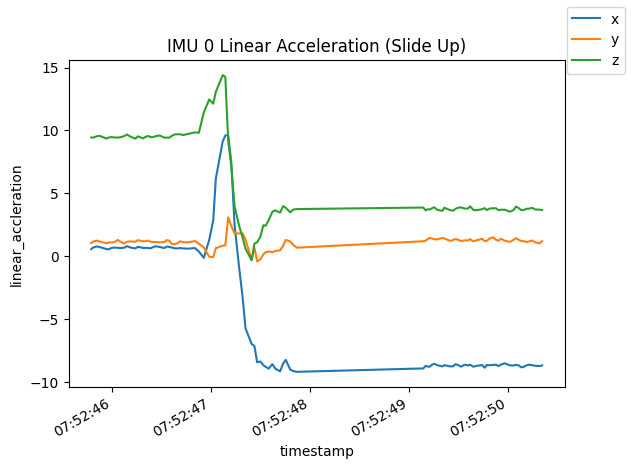

In [23]:
plot_readings(
    slide_up_df,
    "Imu0",
    "IMU 0 Linear Acceleration (Slide Up)",
    "linear_accleration"
)

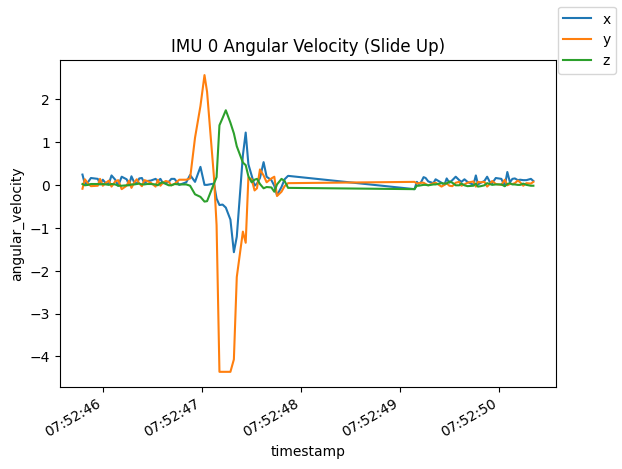

In [24]:
plot_readings(
    slide_up_df,
    "Imu0",
    "IMU 0 Angular Velocity (Slide Up)",
    "angular_velocity"
)

## Slide Down

### Load Data

In [25]:
slide_down_df = pl.read_csv("./imu_data/rosbag/data/data/rosbag2_2023_03_02-05_19_45_data.csv").select(
    ["timestamp"] + get_column_combos(imus, dims, readings)
).with_columns(
    pl.from_epoch("timestamp", time_unit="s")
)

slide_down_df

timestamp,Imu0_linear_accleration_x,Imu0_linear_accleration_y,Imu0_linear_accleration_z,Imu0_angular_velocity_x,Imu0_angular_velocity_y,Imu0_angular_velocity_z,Imu1_linear_accleration_x,Imu1_linear_accleration_y,Imu1_linear_accleration_z,Imu1_angular_velocity_x,Imu1_angular_velocity_y,Imu1_angular_velocity_z
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2023-03-02 05:19:46.163470,-2.13,5.41,7.24,0.12,-0.02,0.04,-7.31,5.4,0.8,0.03,-0.2,0.05
2023-03-02 05:19:46.190725,-2.15,5.51,7.22,0.17,0.03,0.01,-7.56,5.88,0.86,0.08,-0.17,0.09
2023-03-02 05:19:46.219428,-2.2,5.67,7.54,0.13,0.07,-0.0,-7.75,6.22,0.98,0.07,-0.14,0.03
2023-03-02 05:19:46.244259,-2.09,5.86,7.7,0.12,0.07,0.04,-7.92,6.29,1.02,0.03,-0.14,0.05
2023-03-02 05:19:46.270490,-1.99,5.71,7.8,0.12,0.04,0.09,-8.05,6.2,1.04,-0.03,-0.17,0.05
…,…,…,…,…,…,…,…,…,…,…,…,…
2023-03-02 05:19:51.906089,-0.34,6.32,7.2,0.05,0.06,0.02,-6.84,6.28,2.93,0.04,-0.12,-0.01
2023-03-02 05:19:51.933944,-0.27,6.4,7.19,0.11,0.05,-0.0,-6.89,6.34,3.02,0.08,-0.15,0.04
2023-03-02 05:19:51.958693,-0.24,6.43,7.21,0.14,0.05,0.01,-6.73,6.58,3.16,0.08,-0.14,0.04


### Visual

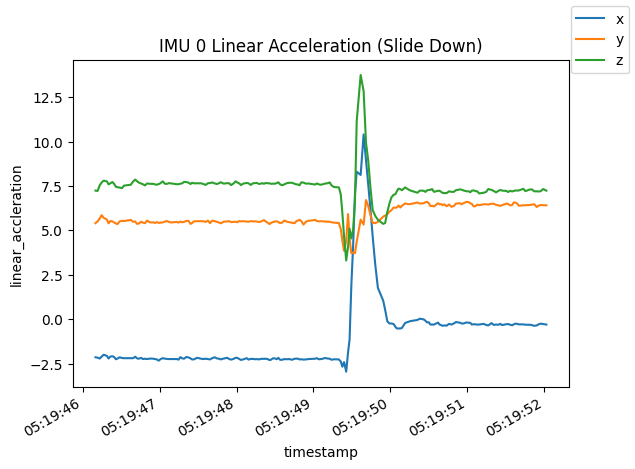

In [26]:
plot_readings(
    slide_down_df,
    "Imu0",
    "IMU 0 Linear Acceleration (Slide Down)",
    "linear_accleration"
)

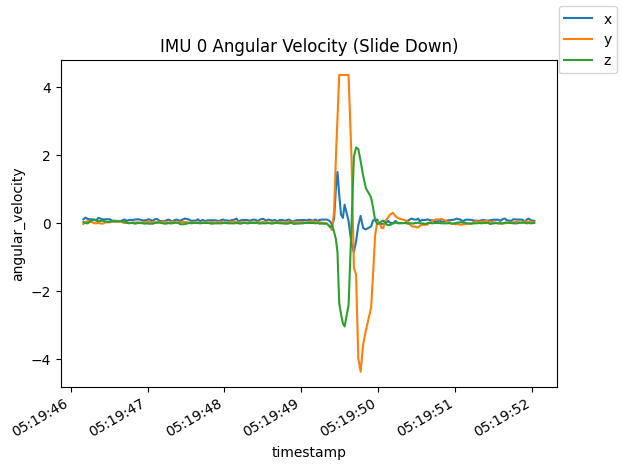

In [27]:
plot_readings(
    slide_down_df,
    "Imu0",
    "IMU 0 Angular Velocity (Slide Down)",
    "angular_velocity"
)

## Nothing

### Load Data

In [28]:
slide_down_df = pl.read_csv("./imu_data/rosbag/data/data/rosbag2_2023_02_27-13_52_46_data.csv").select(
    ["timestamp"] + get_column_combos(imus, dims, readings)
).with_columns(
    pl.from_epoch("timestamp", time_unit="s")
)

slide_down_df

timestamp,Imu0_linear_accleration_x,Imu0_linear_accleration_y,Imu0_linear_accleration_z,Imu0_angular_velocity_x,Imu0_angular_velocity_y,Imu0_angular_velocity_z,Imu1_linear_accleration_x,Imu1_linear_accleration_y,Imu1_linear_accleration_z,Imu1_angular_velocity_x,Imu1_angular_velocity_y,Imu1_angular_velocity_z
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2023-02-27 13:52:49.505854,9.56,2.9,0.62,0.07,0.13,-0.08,7.86,-0.02,7.16,0.1,-0.1,-0.01
2023-02-27 13:52:49.530620,9.6,2.93,0.61,0.06,0.09,-0.05,7.54,0.41,7.12,0.08,-0.1,-0.0
2023-02-27 13:52:49.555358,9.54,2.89,0.65,0.05,0.07,-0.04,7.58,0.34,7.12,0.07,-0.13,-0.03
2023-02-27 13:52:49.610141,9.55,2.95,0.64,0.06,0.05,-0.01,7.58,0.29,7.02,0.06,-0.13,0.01
2023-02-27 13:52:49.632157,9.49,2.96,0.61,0.08,0.03,0.01,7.53,0.35,7.09,0.06,-0.14,0.02
…,…,…,…,…,…,…,…,…,…,…,…,…
2023-02-27 13:52:54.828005,9.79,2.23,-1.39,0.2,0.06,-0.03,5.92,1.3,9.04,0.1,-0.1,0.05
2023-02-27 13:52:54.862217,9.92,2.13,-1.14,0.11,0.12,0.11,5.31,0.63,9.03,-0.05,-0.08,0.07
2023-02-27 13:52:54.888226,9.9,1.89,-1.04,0.13,0.0,0.15,5.56,0.19,8.82,-0.04,-0.15,0.15


### Visual

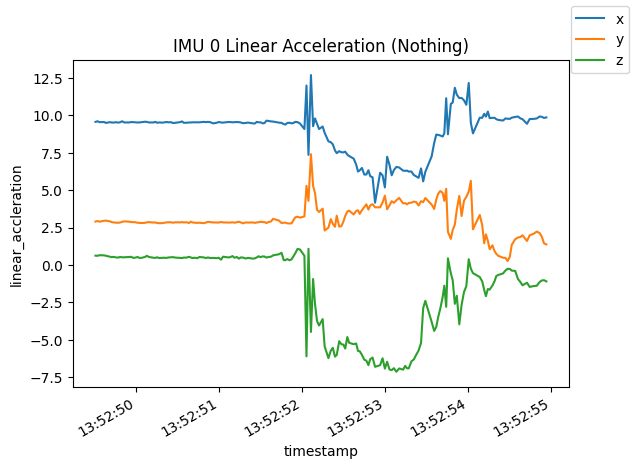

In [29]:
plot_readings(
    slide_down_df,
    "Imu0",
    "IMU 0 Linear Acceleration (Nothing)",
    "linear_accleration"
)

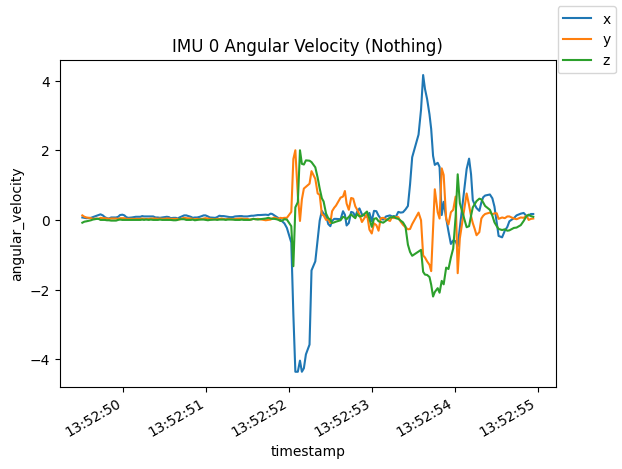

In [30]:
plot_readings(
    slide_down_df,
    "Imu0",
    "IMU 0 Angular Velocity (Nothing)",
    "angular_velocity"
)